In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, utils
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix

print(tf.keras.__version__)

3.10.0


In [3]:
data_dir = "/content/drive/MyDrive/Bone Break Classification/Bone Break Classification"

train_data = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="training",
    shuffle=True,
    seed=40,
    image_size=(256, 256),
    batch_size=64,
    color_mode="rgb"
)

validation_data = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="validation",
    shuffle=True,
    seed=42,
    image_size=(256, 256),
    batch_size=64,
    color_mode="rgb"
)

class_names = train_data.class_names
NUM_CLASSES = len(class_names)
print("Class names:", class_names)

Found 1129 files belonging to 10 classes.
Using 1017 files for training.
Found 1129 files belonging to 10 classes.
Using 225 files for validation.
Class names: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


In [4]:
def preprocess_for_model(img):
    img = tf.cast(img, tf.float32)
    return preprocess_input(img)

def preprocess_for_display(img):
    img = tf.cast(img, tf.float32) / 255.0
    return img

train_dataset = train_data.map(lambda x, y: (preprocess_for_model(x), y))
val_dataset   = validation_data.map(lambda x, y: (preprocess_for_model(x), y))
display_dataset = train_data.map(lambda x, y: (preprocess_for_display(x), y))

In [5]:
def dataset_to_numpy(dataset):
    x_data, y_data = [], []
    for images, labels in dataset:
        x_data.append(images.numpy())
        y_data.append(labels.numpy())
    return np.concatenate(x_data), np.concatenate(y_data)

x_train, y_train = dataset_to_numpy(train_dataset)
x_val, y_val     = dataset_to_numpy(val_dataset)
x_display, y_display = dataset_to_numpy(display_dataset)

In [6]:
y_train = np.squeeze(y_train)
y_val   = np.squeeze(y_val)

y_train = utils.to_categorical(y_train, NUM_CLASSES)
y_val   = utils.to_categorical(y_val, NUM_CLASSES)

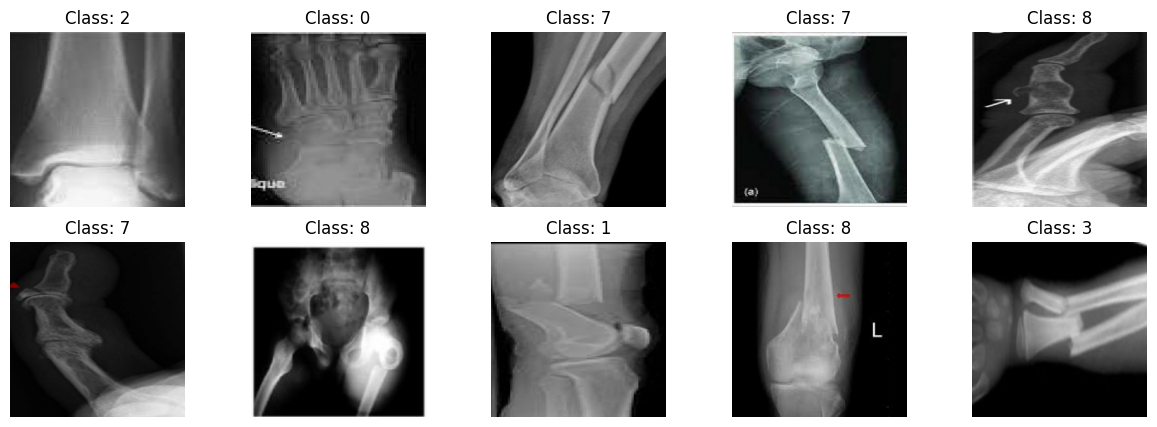

In [7]:
def display(images, labels, n=10):
    idx = np.random.choice(len(images), n, replace=False)
    plt.figure(figsize=(15,5))
    for i, id in enumerate(idx):
        plt.subplot(2,5,i+1)
        plt.imshow(images[id])
        plt.title(f"Class: {labels[id]}")
        plt.axis("off")
    plt.show()

display(x_display, y_display, n=10)

In [8]:
input_layer = layers.Input(shape=(256, 256, 3))

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=input_layer
)
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(520, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output_layer = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_mobilenetv2 = models.Model(input_layer, output_layer)
model_mobilenetv2.summary()


/tmp/ipython-input-2457663088.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,724,770 (10.39 MB)

 Trainable params: 466,786 (1.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
opt = optimizers.RMSprop(learning_rate=0.0001)

model_mobilenetv2.compile(
    optimizer=opt,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model_mobilenetv2.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(x_val, y_val),
    shuffle=True
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.1192 - loss: 2.5582 - val_accuracy: 0.1733 - val_loss: 2.2336
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.1503 - loss: 2.3236 - val_accuracy: 0.2178 - val_loss: 2.1827
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.1767 - loss: 2.2359 - val_accuracy: 0.2844 - val_loss: 2.1296
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.1817 - loss: 2.2283 - val_accuracy: 0.3200 - val_loss: 2.0907
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.2125 - loss: 2.1695 - val_accuracy: 0.3511 - val_loss: 2.0416
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.2580 - loss: 2.0948 - val_accuracy: 0.3467 - val_loss: 1.9948
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.2639 - loss: 2.0641 - val_accuracy: 0.3956 - val_loss: 1.9554
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.2937 - loss: 2.0345 - val_accuracy: 0.4

In [10]:
y_pred_probs = model_mobilenetv2.predict(x_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

print("Accuracy:", accuracy_score(y_true_classes, y_pred_classes))
print("Precision:", precision_score(y_true_classes, y_pred_classes, average='weighted'))
print("Recall:", recall_score(y_true_classes, y_pred_classes, average='weighted'))
print("F1:", f1_score(y_true_classes, y_pred_classes, average='weighted'))
print("Balanced Accuracy:", balanced_accuracy_score(y_true_classes, y_pred_classes))

print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 786ms/step
Accuracy: 0.9111111111111111
Precision: 0.9180612205896004
Recall: 0.9111111111111111
F1: 0.9118509350801588
Balanced Accuracy: 0.9051499729789333
                       precision    recall  f1-score   support

    Avulsion fracture       0.95      1.00      0.98        20
  Comminuted fracture       1.00      0.93      0.96        29
 Fracture Dislocation       0.79      0.97      0.87        31
  Greenstick fracture       0.95      0.90      0.92        20
    Hairline Fracture       0.89      0.93      0.91        27
    Impacted fracture       0.84      0.89      0.86        18
Longitudinal fracture       0.94      0.89      0.91        18
     Oblique fracture       0.88      0.88      0.88        17
Pathological fracture       0.96      0.87      0.91        30
      Spiral Fracture       1.00      0.80      0.89        15

             accuracy                           0.91       225
            macro avg       0.92      0.91      0.91   